In [50]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    GradientBoostingRegressor,
)

In [51]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

from src.data import load_train_test
from src.features import prepare_features
from src.utils import (
    evaluate_model,
    create_submission,
    save_experiment_result,
)

## Загрузка и feature engineering данных

In [52]:
train, test = load_train_test()

train.shape, test.shape

((1460, 81), (1459, 80))

In [53]:
X, y, X_test = prepare_features(train, test)

X.shape, y.shape, X_test.shape

((1460, 86), (1460,), (1459, 86))

## Общий preprocessing

Для честного сравнения все модели получают одинаковую подготовку данных.

Числовые признаки:

- пропуски заполняются медианой;
- признаки масштабируются через `StandardScaler`.

Категориальные признаки:

- пропуски заполняются самым частым значением;
- признаки кодируются через `OneHotEncoder`.

Такой preprocessing уже использовался в baseline и feature engineering экспериментах.

In [54]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

len(numeric_features), len(categorical_features)

(43, 43)

In [55]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    sparse_threshold=0,
)

## Модели для сравнения

Сначала сравним базовые классы моделей:

- `Ridge` -- линейная модель с L2-регуляризацией;
- `Lasso` -- линейная модель с L1-регуляризацией;
- `ElasticNet` -- комбинация L1 и L2 регуляризации;
- `RandomForestRegressor` -- ансамбль деревьев;
- `HistGradientBoostingRegressor` -- быстрый градиентный бустинг из sklearn;
- `GradientBoostingRegressor` -- классический градиентный бустинг из sklearn.

In [56]:
models = {
    "Ridge": Ridge(alpha=20),
    "Lasso": Lasso(
        alpha=0.0005,
        max_iter=10000,
        random_state=42,
    ),
    "ElasticNet": ElasticNet(
        alpha=0.0005,
        l1_ratio=0.5,
        max_iter=10000,
        random_state=42,
    ),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
    ),
    "HistGradientBoostingRegressor": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42,
    ),
    "GradientBoostingRegressor": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
    ),
}

## Сравнение моделей через cross-validation

Все модели оцениваются одинаково:

- 5-fold KFold;
- shuffle=True;
- random_state=42;
- метрика: RMSE по `log1p(SalePrice)`.

In [57]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [58]:
model_results = []

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    cv_rmse, cv_std, scores = evaluate_model(
        pipeline,
        X,
        y,
        cv,
    )

    model_results.append(
        {
            "Model": model_name,
            "CV RMSE": round(cv_rmse, 5),
            "CV std": round(cv_std, 5),
        }
    )

    print(f"{model_name}")
    print(f"CV RMSE: {cv_rmse:.5f}")
    print(f"CV std:  {cv_std:.5f}")
    print("-" * 40)

Ridge
CV RMSE: 0.14702
CV std:  0.04052
----------------------------------------
Lasso
CV RMSE: 0.14171
CV std:  0.04326
----------------------------------------
ElasticNet
CV RMSE: 0.14300
CV std:  0.04132
----------------------------------------
RandomForestRegressor
CV RMSE: 0.14206
CV std:  0.01889
----------------------------------------
HistGradientBoostingRegressor
CV RMSE: 0.13162
CV std:  0.01786
----------------------------------------
GradientBoostingRegressor
CV RMSE: 0.13224
CV std:  0.01683
----------------------------------------


In [59]:
model_results_df = (
    pd.DataFrame(model_results)
    .sort_values("CV RMSE")
    .reset_index(drop=True)
)

model_results_df

,Model,CV RMSE,CV std
0,HistGradientBoostingRegressor,0.13162,0.01786
1,GradientBoostingRegressor,0.13224,0.01683
2,Lasso,0.14171,0.04326
3,RandomForestRegressor,0.14206,0.01889
4,ElasticNet,0.14300,0.04132
5,Ridge,0.14702,0.04052


## Визуализация CV RMSE

Построим график локального CV RMSE для сравниваемых моделей.

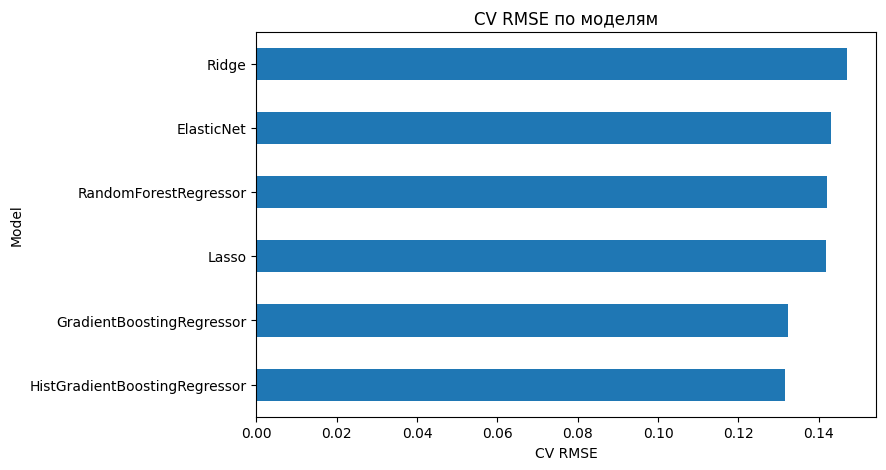

In [60]:
plt.figure(figsize=(8, 5))

(
    model_results_df
    .sort_values("CV RMSE", ascending=True)
    .plot(
        x="Model",
        y="CV RMSE",
        kind="barh",
        legend=False,
        ax=plt.gca(),
    )
)

plt.title("CV RMSE по моделям")
plt.xlabel("CV RMSE")
plt.ylabel("Model")
plt.show()

## Комментарий по HistGradientBoostingRegressor

По результатам cross-validation лучший средний CV RMSE показал `HistGradientBoostingRegressor`.

Однако в текущем pipeline после `OneHotEncoder(sparse_output=False)` категориальные признаки превращаются в плотную one-hot матрицу. Такой preprocessing не является оптимальным для `HistGradientBoostingRegressor`.

Поэтому на этом этапе модель оставлена в таблице CV-результатов, но не включена в submission-цикл.

Для неё нужен отдельный preprocessing pipeline:

- числовые признаки без масштабирования;
- категориальные признаки через `OrdinalEncoder`;
- отдельный подбор гиперпараметров.

К этой модели стоит вернуться на следующем этапе вместе с другими tree-based и boosting-моделями.

In [61]:
results_path = PROJECT_ROOT / "reports" / "model_results.csv"

experiment_ids = {
    "Ridge": "5",
    "Lasso": "6",
    "ElasticNet": "7",
    "RandomForestRegressor": "8",
    "HistGradientBoostingRegressor": "9",
    "GradientBoostingRegressor": "10",
}

## Kaggle scores

Результаты Kaggle записываются вручную после загрузки submission-файлов.

`HistGradientBoostingRegressor` не отправлялся на Kaggle, потому что финальное обучение в текущем pipeline оказалось слишком долгим.

In [62]:
kaggle_scores = {
    "5": 0.13261,  # Ridge
    "6": 0.13277,  # Lasso
    "7": 0.13429,  # ElasticNet
    "8": 0.14325,  # RandomForestRegressor
    "9": np.nan,   # HistGradientBoostingRegressor не отправлялся
    "10": 0.13680,  # GradientBoostingRegressor
}

In [63]:
results = None

for model_name, experiment_id in experiment_ids.items():
    row = model_results_df[
        model_results_df["Model"] == model_name
    ].iloc[0]

    results = save_experiment_result(
        results_path=results_path,
        experiment=experiment_id,
        model_name=model_name,
        cv_rmse=row["CV RMSE"],
        cv_std=row["CV std"],
        kaggle_score=kaggle_scores.get(experiment_id, np.nan),
        notes="model comparison with feature engineering",
    )

results

,Experiment,Model,CV RMSE,CV std,Kaggle score,Notes
0,001,Ridge,0.14679,0.03932,0.13375,baseline
1,002,Ridge,0.11489,0.00818,0.13435,feature engineering + outlier removal
2,003,Ridge,0.14711,0.03976,0.13360,feature engineering without outlier removal
3,004,Ridge tuned,0.14700,0.03976,0.13262,feature engineering + tuned alpha without outl...
4,005,Ridge,0.14702,0.04052,0.13261,model comparison with feature engineering
5,006,Lasso,0.14171,0.04326,0.13277,model comparison with feature engineering
6,007,ElasticNet,0.14300,0.04132,0.13429,model comparison with feature engineering
7,008,RandomForestRegressor,0.14206,0.01889,0.14325,model comparison with feature engineering
8,009,HistGradientBoostingRegressor,0.13162,0.01786,NaN,model comparison with feature engineering
9,010,GradientBoostingRegressor,0.13224,0.01683,0.13680,model comparison with feature engineering


In [64]:
submission_filenames = {
    "Ridge": "submission_5_ridge.csv",
    "Lasso": "submission_6_lasso.csv",
    "ElasticNet": "submission_7_elasticnet.csv",
    "RandomForestRegressor": "submission_8_random_forest.csv",
    "GradientBoostingRegressor": "submission_10_gradient_boosting.csv",
}

In [65]:
trained_pipelines = {}

for model_name, filename in submission_filenames.items():
    print(f"Обучение модели: {model_name}")

    model = models[model_name]

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    pipeline.fit(X, y)

    submission = create_submission(
        model=pipeline,
        X_test=X_test,
        test_ids=test["Id"],
        output_path=PROJECT_ROOT / "submissions" / filename,
    )

    trained_pipelines[model_name] = pipeline

    print(f"Submission сохранён: {filename}")
    print("-" * 50)

Обучение модели: Ridge
Submission сохранён: submission_5_ridge.csv
--------------------------------------------------
Обучение модели: Lasso
Submission сохранён: submission_6_lasso.csv
--------------------------------------------------
Обучение модели: ElasticNet
Submission сохранён: submission_7_elasticnet.csv
--------------------------------------------------
Обучение модели: RandomForestRegressor
Submission сохранён: submission_8_random_forest.csv
--------------------------------------------------
Обучение модели: GradientBoostingRegressor
Submission сохранён: submission_10_gradient_boosting.csv
--------------------------------------------------


## Итоги моделирования

На этом этапе были сравнены несколько классов моделей:

- линейные модели;
- случайный лес;
- градиентный бустинг из scikit-learn.

### Что показали результаты

Лучший Kaggle score среди отправленных моделей показала `Ridge Regression`:

- `Ridge`: `0.13261`;
- `Lasso`: `0.13277`;
- `ElasticNet`: `0.13429`;
- `RandomForestRegressor`: `0.14325`;
- `GradientBoostingRegressor`: `0.13680`.

`HistGradientBoostingRegressor` показал лучший локальный CV RMSE, но не был отправлен на Kaggle в текущем раунде, потому что общий dense one-hot preprocessing не является оптимальным для этой модели. Для неё нужен отдельный tree-specific preprocessing pipeline.

### Основные наблюдения

Более сложные модели не улучшили результат автоматически.

`RandomForestRegressor` и `GradientBoostingRegressor` показали худший Kaggle score, чем регуляризованные линейные модели.

Это говорит о том, что текущее признаковое пространство хорошо подходит для линейных моделей, а деревья и бустинг требуют отдельной настройки гиперпараметров и, возможно, другого preprocessing.

На текущем этапе лучшей моделью остаётся `Ridge Regression`.

### Следующие шаги

Дальше можно двигаться в двух направлениях:

1. Улучшить линейные модели:
   - подобрать `alpha` для Ridge, Lasso и ElasticNet;
   - попробовать усреднение Ridge + Lasso;
   - сделать отбор признаков.

2. Отдельно настроить бустинги:
   - попробовать XGBoost;
   - попробовать CatBoost;
   - попробовать LightGBM;
   - подобрать гиперпараметры;
   - проверить другой preprocessing для категориальных признаков.